# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [2]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Turning off future warnings for cleaner output in this notebook
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/docs/stable/torchvision/datasets.html#cifar)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [8]:
# Set batch size for training and testing dataloaders
train_batch_size = 64
test_batch_size = 64

# Define transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])    

# Create training set and define training dataloader
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=train_batch_size, shuffle=True)


# Create test set and define test dataloader
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=test_batch_size, shuffle=False)

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [9]:
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])    
        image = images[i].numpy()

        # Unnormalize the image for display
        image = (image * 0.5) + 0.5

        # If a training image, transpose and rotate it for correct orientation to be displayed
        if img_loader == trainloader:
            image = np.rot90(image.T, k=3)

        plt.imshow(image)
        plt.show()

plane


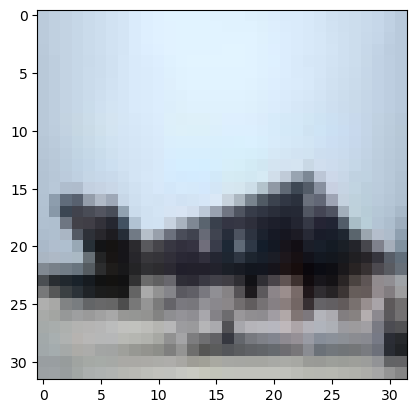

bird


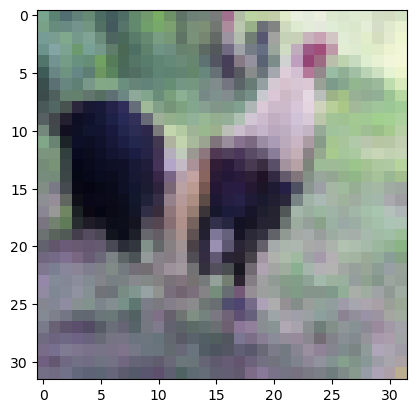

dog


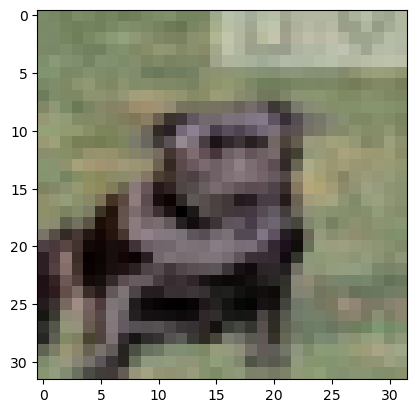

plane


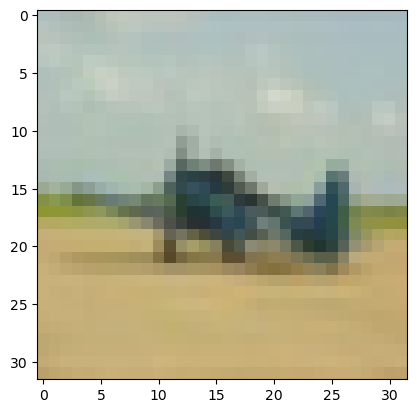

dog


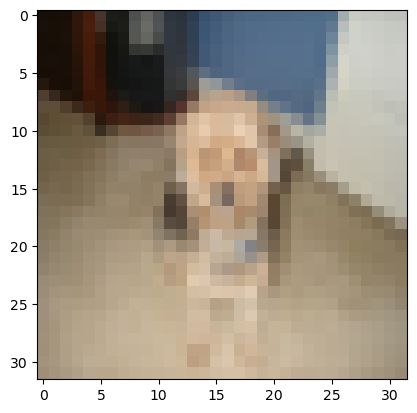

In [10]:
# Show 5 images from the training set with their labels
show5(img_loader=trainloader)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].


cat


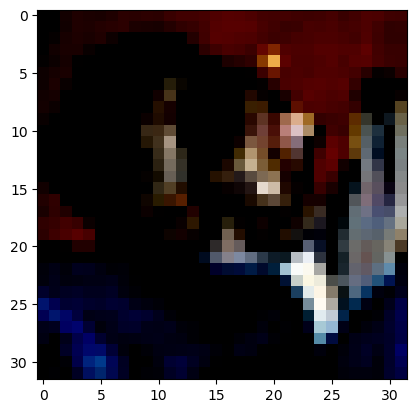

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9372549].


ship


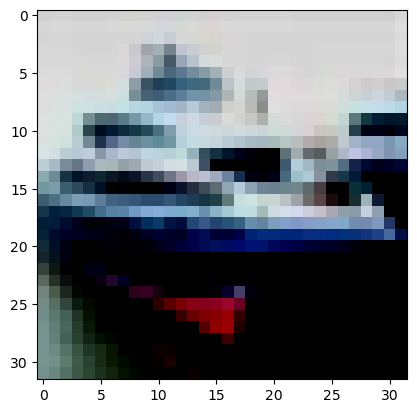

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.9764706].


ship


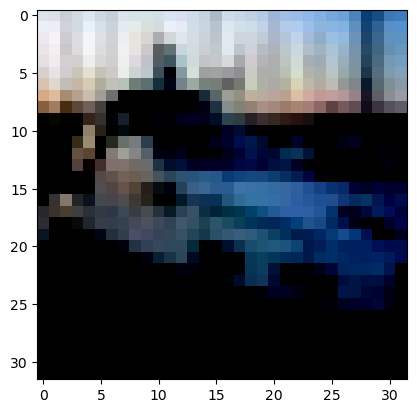

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7411765..0.8352941].


plane


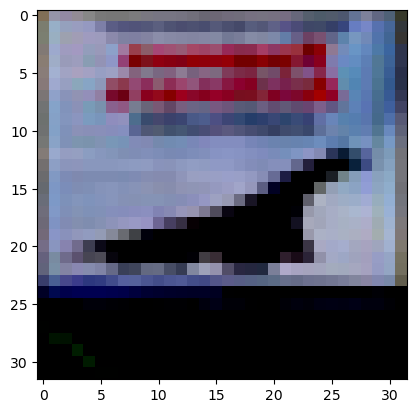

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.7254902].


frog


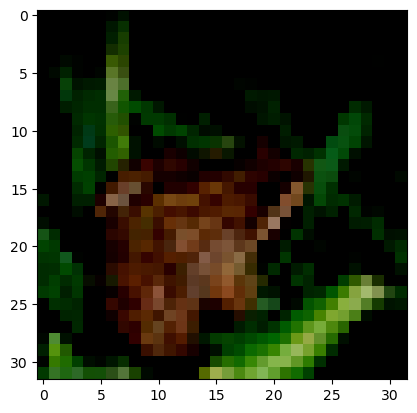

In [21]:
# Show 5 images from the test set with their labels
show5(img_loader=testloader)

In [73]:
# Show the shapes of the images and labels from the training set
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(f"The shape of the training images is: {images.shape}") # 64 images, 3 color channels, 32x32 pixels
print(f"The shape of the training labels is: {labels.shape}") # 64 labels

The shape of the training images is: torch.Size([64, 3, 32, 32])
The shape of the training labels is: torch.Size([64])


In [70]:
# Show size of the training and test sets
print(f"The training set contains {len(trainset)} images.")
print(f"The test set contains {len(testset)} images.")

The training set contains 50000 images.
The test set contains 10000 images.


## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [27]:
# Create a convolutional neural network, which works great for image classification
class MyNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        # Defining the convulational layers
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.2)

        # Defining the fully connected layers
        self.fc1 = nn.Linear(64 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 10)
        self.fc3 = nn.Linear(10, 10)
        
    def forward(self, x):
        # Define forward pass through the network
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), 64 * 6 * 6)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))
        # Apply softmax to output layer
        return F.softmax(x, dim=1)
    
# Initialize my model
model = MyNeuralNetwork()

<!-- Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment. -->

In [28]:
# Define the loss function and optimizer
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [30]:
# Set up the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Setting additional necessary variables for training loop
epochs = 40
train_losses = []
test_losses = []
total_accuracy = []

for e in range(epochs):
    running_loss = 0.0
    model.train()  # Set the model to training mode

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(torch.log(outputs + 1e-8), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    else:
        total_test_loss = 0
        correct = 0 # Tracks correct predictions for test set

        # Disable gradients for validation phase to preserve resources
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(torch.log(outputs + 1e-8), labels)
                total_test_loss += loss.item()

                ps = torch.exp(outputs)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                correct += equals.sum().item()

        total_accuracy.append(correct/len(testloader.dataset))
        avg_train_loss = running_loss / len(trainloader)
        avg_test_loss = total_test_loss / len(testloader)

        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)

        print(f"Epoch #{e+1}: | Avg. Train Loss: {avg_train_loss:.4f} | Avg. Test Loss: {avg_test_loss:.4f} | Avg. Test Accuracy: {correct/len(testloader.dataset):.4f}")


Epoch #1: | Avg. Train Loss: 1.2931 | Avg. Test Loss: 1.4777 | Avg. Test Accuracy: 0.5213
Epoch #2: | Avg. Train Loss: 1.2849 | Avg. Test Loss: 1.4862 | Avg. Test Accuracy: 0.5175
Epoch #3: | Avg. Train Loss: 1.2571 | Avg. Test Loss: 1.4609 | Avg. Test Accuracy: 0.5219
Epoch #4: | Avg. Train Loss: 1.2398 | Avg. Test Loss: 1.4366 | Avg. Test Accuracy: 0.5376
Epoch #5: | Avg. Train Loss: 1.2239 | Avg. Test Loss: 1.4633 | Avg. Test Accuracy: 0.5222
Epoch #6: | Avg. Train Loss: 1.2093 | Avg. Test Loss: 1.4449 | Avg. Test Accuracy: 0.5330
Epoch #7: | Avg. Train Loss: 1.1965 | Avg. Test Loss: 1.4447 | Avg. Test Accuracy: 0.5341
Epoch #8: | Avg. Train Loss: 1.1896 | Avg. Test Loss: 1.4463 | Avg. Test Accuracy: 0.5330
Epoch #9: | Avg. Train Loss: 1.1688 | Avg. Test Loss: 1.4297 | Avg. Test Accuracy: 0.5385
Epoch #10: | Avg. Train Loss: 1.1649 | Avg. Test Loss: 1.4359 | Avg. Test Accuracy: 0.5411
Epoch #11: | Avg. Train Loss: 1.1560 | Avg. Test Loss: 1.4868 | Avg. Test Accuracy: 0.5266
Epoch #1

KeyboardInterrupt: 

Plot the training loss (and validation loss/accuracy, if recorded).

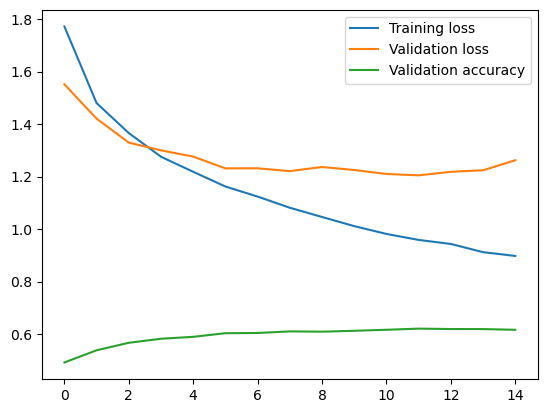

In [ ]:
# Plot training and validation losses over epochs
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend()
plt.show()

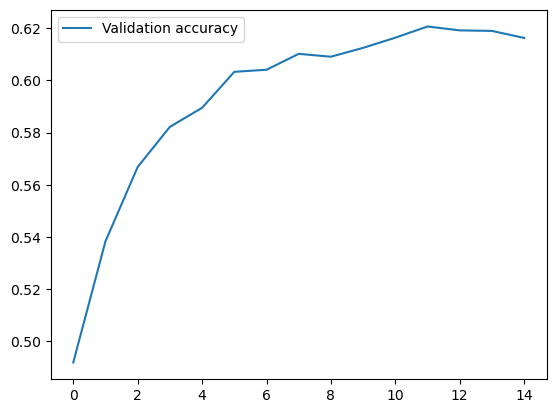

In [ ]:
# Plot validation accuracy over epochs
plt.plot(total_accuracy, label='Validation accuracy')
plt.legend()
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [66]:
# Insert code here
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        ps = torch.exp(outputs)
        top_p, top_class = ps.topk(1, dim=1)
        equals = top_class == labels.view(*top_class.shape)
        correct += equals.sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {correct/total:.4f}")

Test Accuracy: 0.7612


## Saving your model
Using `torch.save`, save your model for future loading.

In [ ]:
torch.save(model.state_dict(), 'cifar10_model.pth')

## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.



**Double click this cell to modify it**

